In [194]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [195]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
dataset = pd.read_csv("heart_disease dataset.csv")

print(dataset.head(10))

Saving heart_disease dataset.csv to heart_disease dataset.csv
   Unnamed: 0  male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1073     1   48          1              0           0       0   
1         953     0   39          1              1           5       0   
2        2584     0   43          1              1           1       0   
3        3068     0   46          3              1          30       0   
4        1826     0   38          2              0           0       0   
5        1104     1   57          4              0           0       0   
6        3414     0   57          2              0           0       0   
7        3987     0   51          4              0           0       0   
8        3520     0   56          3              0           0       0   
9        2270     1   43          2              1          15       0   

   prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                0             0         0     

In [196]:
print(dataset.shape)
print(dataset.isnull().sum())
print(dataset.isnull().sum().sum())
dataset.shape

(3646, 17)
Unnamed: 0         0
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64
0


(3646, 17)

In [197]:
dataset.drop_duplicates(inplace=True)
dataset.shape
dataset = dataset.iloc[:, 1:]
dataset.drop("education",axis=1,inplace=True)
print(dataset.head(3))

   male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   48              0           0       0                0   
1     0   39              1           5       0                0   
2     0   43              1           1       0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0      181  153.0   93.0  29.34        103       88   
1             0         0      170  137.5   77.5  27.35         67       70   
2             0         0      256  129.0   86.0  25.89         96       72   

   TenYearCHD  
0           0  
1           0  
2           0  


In [198]:
#outlier
dataset.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000
mean,0.429238,49.569117,0.496160,8.900439,0.029073,0.005485,0.310752,0.025233,236.792101,132.419638,82.933489,25.827150,75.890839,81.289632,0.150850
std,0.495035,8.589496,0.500054,11.803499,0.168034,0.073871,0.462865,0.156854,44.356532,22.127895,11.926433,4.116544,12.043366,22.632328,0.357952
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,116.500000,75.000000,23.060000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.405000,75.000000,77.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,143.500000,89.875000,28.060000,83.000000,85.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,248.000000,142.500000,56.800000,140.000000,394.000000,1.000000


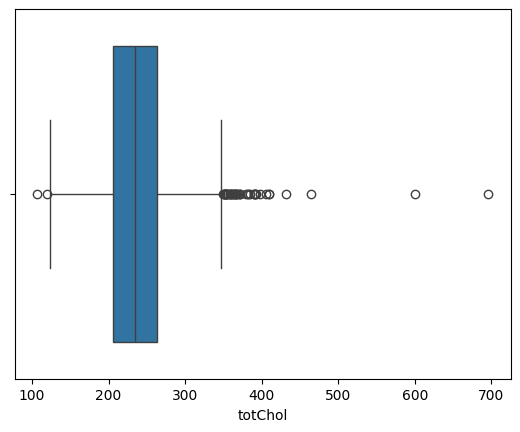

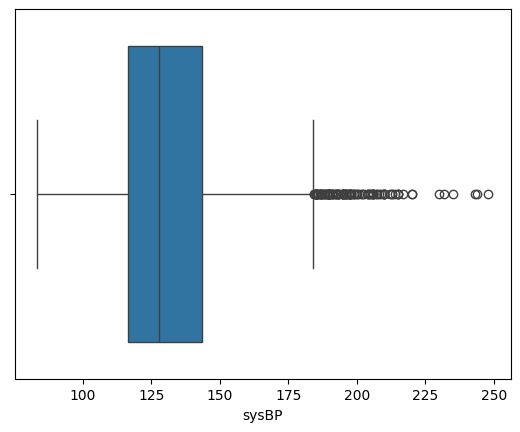

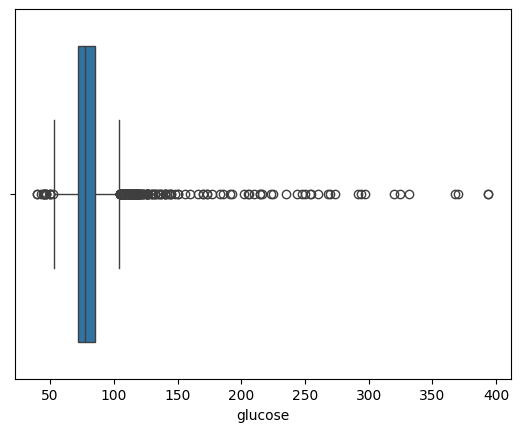

In [199]:
#detect outlier
sns.boxplot(x="totChol", data=dataset)
plt.show()
sns.boxplot(x="sysBP", data=dataset)
plt.show()
sns.boxplot(x="glucose", data=dataset)
plt.show()

In [200]:
# remove outliers by z score
min_range=dataset["totChol"].mean()-(3*dataset["totChol"].std())
max_range=dataset["totChol"].mean()+(3*dataset["totChol"].std())
print(min_range,max_range)
dataset=dataset[dataset["totChol"] <= max_range]

103.72250610366416 369.86169576139343


In [201]:
# remove outliers by z score
min_range=dataset["sysBP"].mean()-(3*dataset["sysBP"].std())
max_range=dataset["sysBP"].mean()+(3*dataset["sysBP"].std())
print(min_range,max_range)
dataset=dataset[dataset["sysBP"] <= max_range]

66.04205539949749 198.62727719840655


In [202]:
# remove outliers by z score
min_range=dataset["glucose"].mean()-(3*dataset["glucose"].std())
max_range=dataset["glucose"].mean()+(3*dataset["glucose"].std())
print(min_range,max_range)
dataset=dataset[dataset["glucose"] <= max_range]

17.5426587367578 144.3429120140097


In [203]:

dataset.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.00000
mean,0.431959,49.363919,0.502541,9.015528,0.026821,0.005082,0.297854,0.012140,235.480237,131.227132,82.521739,25.767606,75.686900,79.261717,0.14201
std,0.495419,8.537439,0.500064,11.838699,0.161583,0.071116,0.457380,0.109526,41.713754,20.269847,11.355160,4.045096,11.954987,12.656101,0.34911
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.00000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,116.000000,74.500000,23.030000,68.000000,72.000000,0.00000
50%,0.000000,48.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,77.000000,0.00000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,142.000000,89.000000,27.990000,82.000000,85.000000,0.00000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,366.000000,198.000000,130.000000,56.800000,140.000000,144.000000,1.00000


In [204]:
#feature scaling Normalization
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

num_cols = ["male","age","currentSmoker",	"cigsPerDay",	"BPMeds","prevalentStroke",	"prevalentHyp",	"diabetes",	"totChol"	,"sysBP","diaBP",	"BMI",	"heartRate",	"glucose"]

for i in num_cols:
    dataset[i] = ms.fit_transform(dataset[[i]])

print(dataset.head(3))

   male       age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0   1.0  0.421053            0.0    0.000000     0.0              0.0   
1   0.0  0.184211            1.0    0.071429     0.0              0.0   
2   0.0  0.289474            1.0    0.014286     0.0              0.0   

   prevalentHyp  diabetes   totChol     sysBP     diaBP       BMI  heartRate  \
0           0.0       0.0  0.285714  0.606987  0.548780  0.334464   0.614583   
1           0.0       0.0  0.243243  0.471616  0.359756  0.286234   0.239583   
2           0.0       0.0  0.575290  0.397380  0.463415  0.250848   0.541667   

    glucose  TenYearCHD  
0  0.461538           0  
1  0.288462           0  
2  0.307692           0  


In [205]:
#check imbalancing in output columne CHD
x=dataset.iloc[:,:-1]
y=dataset["TenYearCHD"]
print(y.value_counts())  #shows imbalancing
from imblearn.over_sampling import RandomOverSampler
ro=RandomOverSampler(random_state=42)
ro_input_data,ro_output_data= ro.fit_resample(x,y)
print(ro_output_data.value_counts()) #balanced output

TenYearCHD
0    3039
1     503
Name: count, dtype: int64
TenYearCHD
0    3039
1    3039
Name: count, dtype: int64


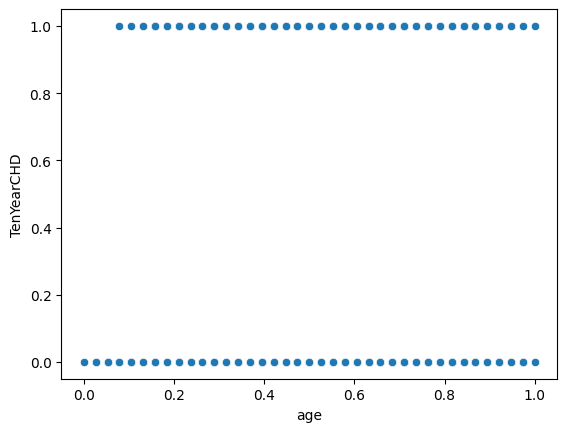

In [206]:
# select ml model
sns.scatterplot(x="age", y="TenYearCHD", data=dataset)
plt.show()
# sigmoid function curve , can use logistic regression

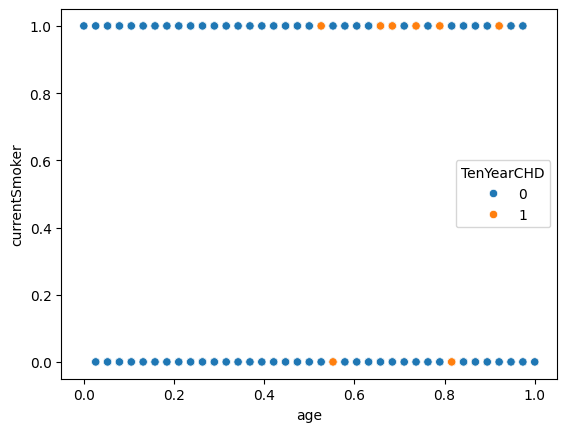

In [207]:
sns.scatterplot(x="age", y="currentSmoker",data=dataset, hue="TenYearCHD")
plt.show()

In [208]:
"""from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ro_input_data,ro_output_data,test_size=0.25,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train, y_train)"""

'from sklearn.model_selection import train_test_split\nx_train, x_test, y_train, y_test = train_test_split(ro_input_data,ro_output_data,test_size=0.25,random_state=42)\nprint(x_train.shape)\nprint(x_test.shape)\nprint(y_train.shape)\nprint(y_test.shape)\nfrom sklearn.tree import DecisionTreeClassifier\ndt=DecisionTreeClassifier()\ndt.fit(x_train, y_train)'

In [209]:
#dt.score(x_test,y_test)*100

In [210]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ro_input_data,ro_output_data,test_size=0.25,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4558, 14)
(1520, 14)
(4558,)
(1520,)


In [255]:
from sklearn.ensemble import RandomForestClassifier
neigh=RandomForestClassifier()
neigh.fit(x_train, y_train)

RandomForestClassifier()

In [256]:
neigh.score(x_test,y_test)*100

97.89473684210527

In [257]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
cf=confusion_matrix(y_test,neigh.predict(x_test))
cf

array([[767,  27],
       [  5, 721]])

<Axes: >

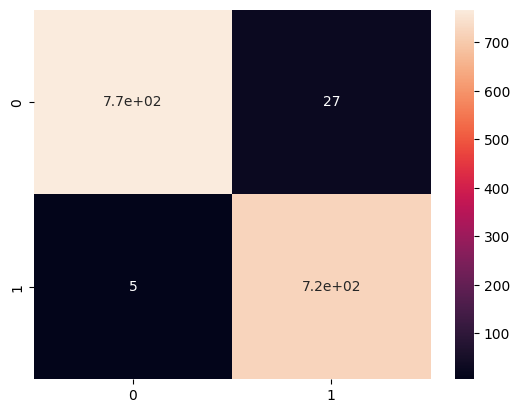

In [258]:
import seaborn as sns
sns.heatmap(cf,annot=True)

In [259]:
precision_score(y_test,neigh.predict(x_test))*100

96.3903743315508

In [260]:
f1_score(y_test,neigh.predict(x_test))*100

97.82903663500679

In [261]:
recall_score(y_test,neigh.predict(x_test))*100

99.31129476584022

In [262]:
pred = neigh.fit(x_train, y_train).predict(x_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       794
           1       0.96      0.99      0.97       726

    accuracy                           0.98      1520
   macro avg       0.98      0.98      0.98      1520
weighted avg       0.98      0.98      0.98      1520

